In [ ]:
!pip install mlflow -q
print("MLflow installed ✓")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 98.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.5/879.5 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

%matplotlib inline
sns.set_theme(style="whitegrid")

print("All imports successful ✓")


All imports successful ✓


In [ ]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nTarget column: MedHouseVal (median house value in $100,000s)")


Dataset shape: (20640, 9)

Column names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']

Target column: MedHouseVal (median house value in $100,000s)


In [ ]:
print("=== First 5 rows ===")
display(df.head())

print("\n=== Column types and null counts ===")
df.info()

=== First 5 rows ===


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



=== Column types and null counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [ ]:
print("=== Statistical Summary ===")
display(df.describe().round(2))

print("\n=== Missing values per column ===")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")



=== Statistical Summary ===


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00



=== Missing values per column ===
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Total missing values: 0


In [ ]:
feature_descriptions = {
    "MedInc":       "Median income in block group (tens of thousands $)",
    "HouseAge":     "Median house age in block group (years)",
    "AveRooms":     "Average number of rooms per household",
    "AveBedrms":    "Average number of bedrooms per household",
    "Population":   "Block group population",
    "AveOccup":     "Average number of household members",
    "Latitude":     "Block group latitude",
    "Longitude":    "Block group longitude",
    "MedHouseVal":  "TARGET: Median house value in $100,000s"
}

print("=== Feature Descriptions ===")
for col, desc in feature_descriptions.items():
    print(f"  {col:15s}: {desc}")

=== Feature Descriptions ===
  MedInc         : Median income in block group (tens of thousands $)
  HouseAge       : Median house age in block group (years)
  AveRooms       : Average number of rooms per household
  AveBedrms      : Average number of bedrooms per household
  Population     : Block group population
  AveOccup       : Average number of household members
  Latitude       : Block group latitude
  Longitude      : Block group longitude
  MedHouseVal    : TARGET: Median house value in $100,000s


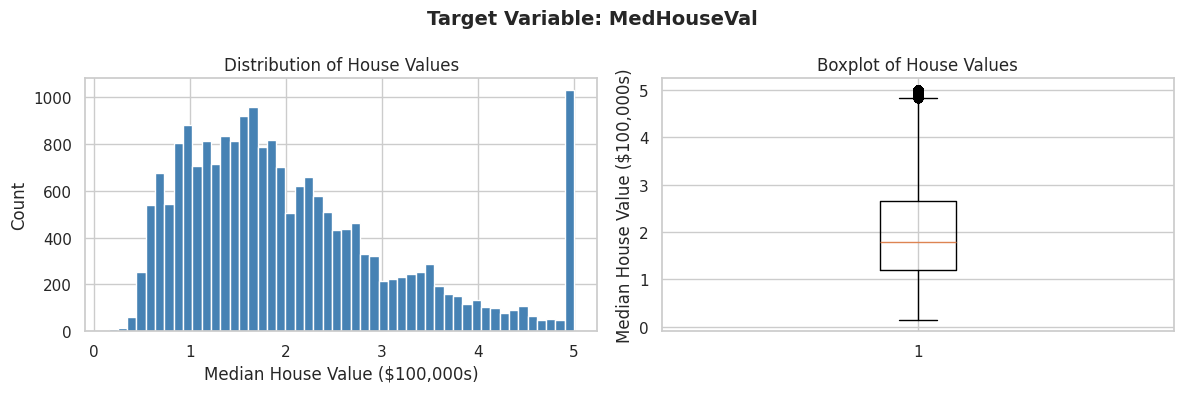

Skewness: 0.978
Note: Values are capped at 5.0 — you'll see a spike at the right end


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["MedHouseVal"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution of House Values")
axes[0].set_xlabel("Median House Value ($100,000s)")
axes[0].set_ylabel("Count")

axes[1].boxplot(df["MedHouseVal"], vert=True)
axes[1].set_title("Boxplot of House Values")
axes[1].set_ylabel("Median House Value ($100,000s)")

plt.suptitle("Target Variable: MedHouseVal", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Skewness: {df['MedHouseVal'].skew():.3f}")
print("Note: Values are capped at 5.0 — you'll see a spike at the right end")



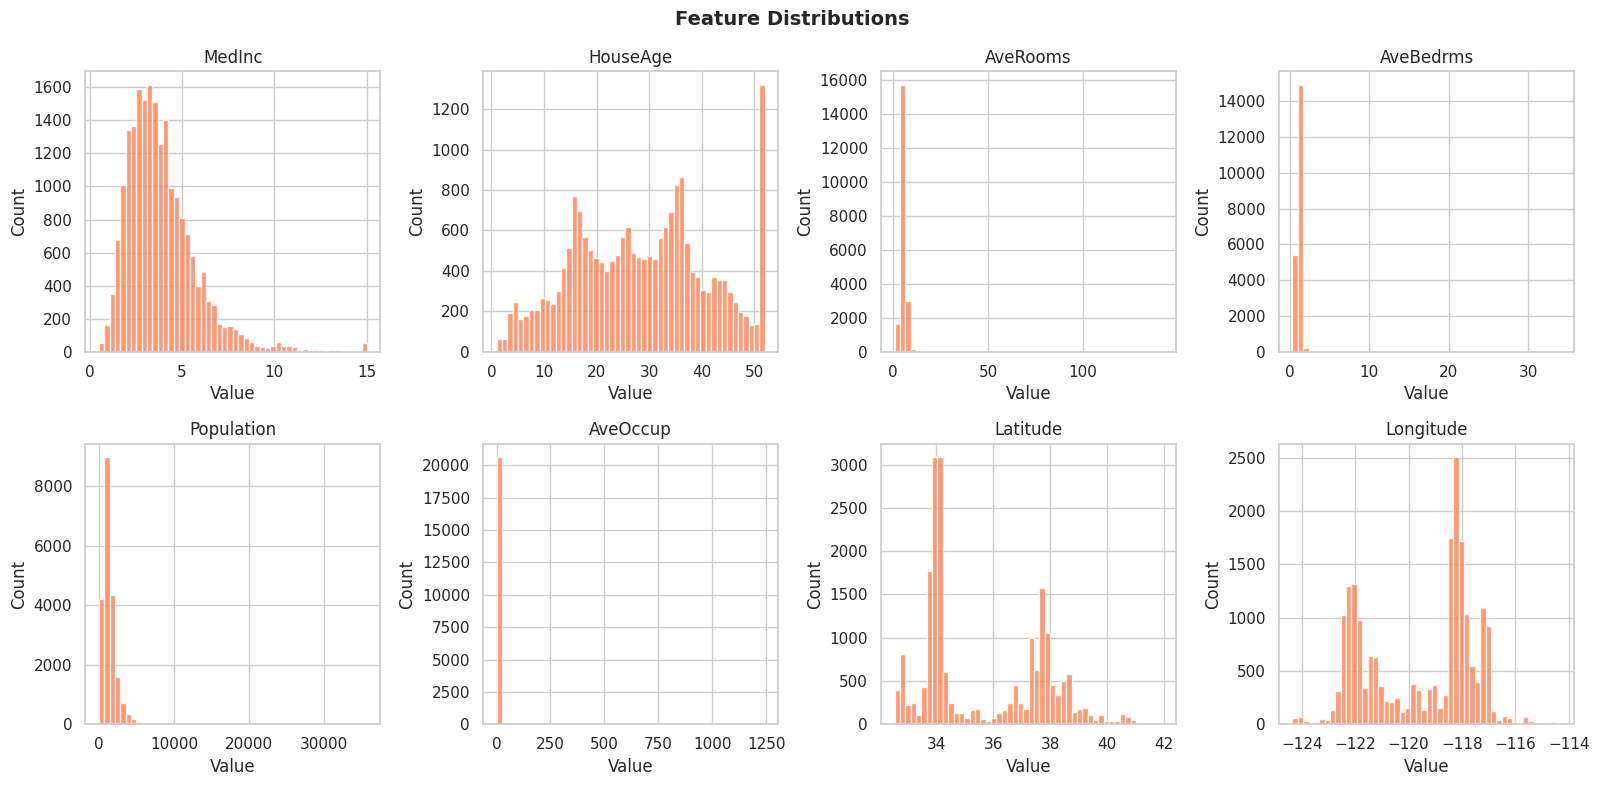

In [ ]:
features = [col for col in df.columns if col != "MedHouseVal"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].hist(df[feature], bins=50, color="coral", edgecolor="white", alpha=0.8)
    axes[i].set_title(feature)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")

plt.suptitle("Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

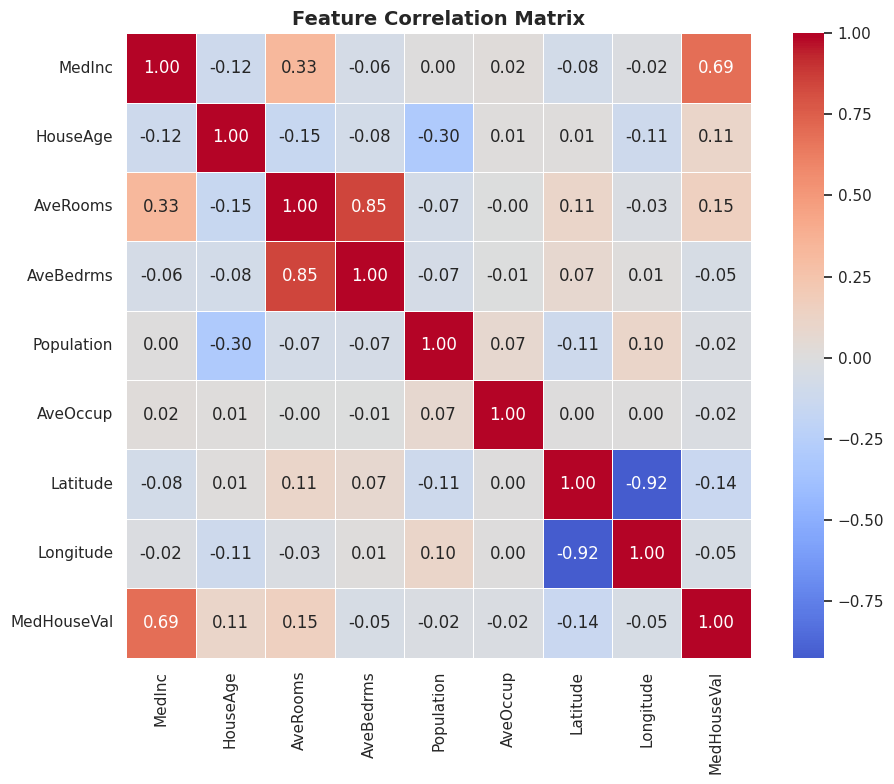


=== Correlation with Target (MedHouseVal) ===
MedInc        0.688
AveRooms      0.152
HouseAge      0.106
AveOccup     -0.024
Population   -0.025
Longitude    -0.046
AveBedrms    -0.047
Latitude     -0.144
Name: MedHouseVal, dtype: float64


In [ ]:
correlation_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n=== Correlation with Target (MedHouseVal) ===")
target_corr = correlation_matrix["MedHouseVal"].drop("MedHouseVal").sort_values(ascending=False)
print(target_corr.round(3))

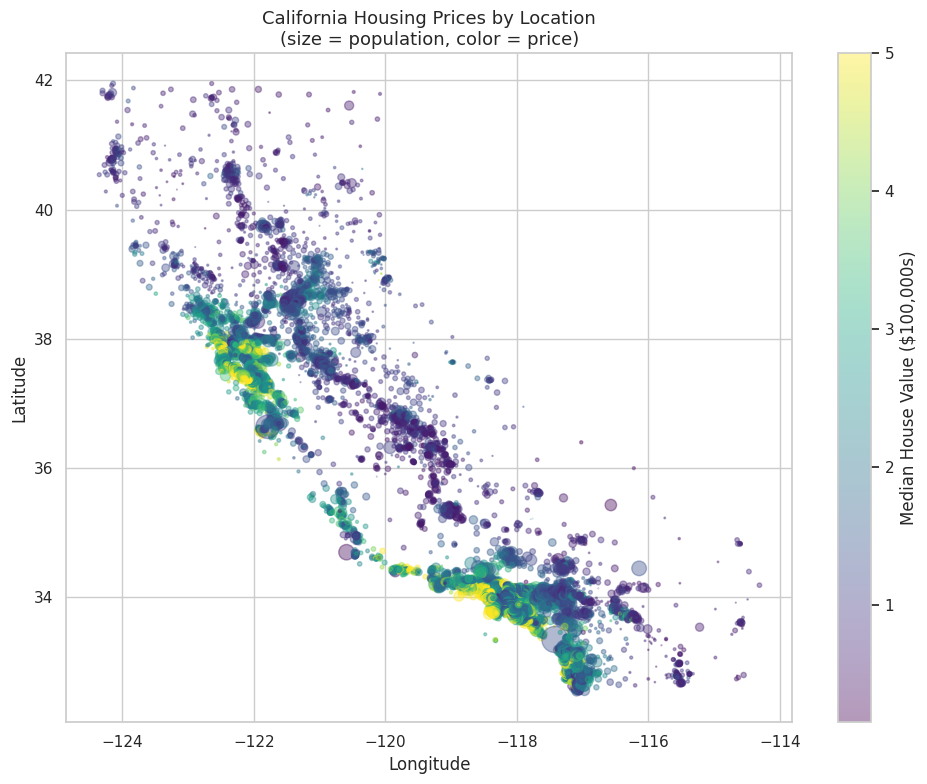

You should see the California coastline, with expensive clusters near SF and LA


In [ ]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    df["Longitude"],
    df["Latitude"],
    c=df["MedHouseVal"],
    cmap="viridis",
    alpha=0.4,
    s=df["Population"] / 100
)
plt.colorbar(scatter, label="Median House Value ($100,000s)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("California Housing Prices by Location\n(size = population, color = price)", fontsize=13)
plt.tight_layout()
plt.show()

print("You should see the California coastline, with expensive clusters near SF and LA")

In [ ]:
output_path = "california_housing.csv"
df.to_csv(output_path, index=False)

print(f"✓ Raw data saved to: {output_path}")
print(f"  Shape: {df.shape}")
print(f"  Columns: {df.columns.tolist()}")

✓ Raw data saved to: california_housing.csv
  Shape: (20640, 9)
  Columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


In [ ]:
print("=" * 55)
print("EDA SUMMARY — Key Findings for Day 2")
print("=" * 55)
print(f"""
DATASET:
  • 20,640 samples, 8 features + 1 target
  • No missing values
  • Target: MedHouseVal (median house value in $100,000s)

SCALE ISSUES (we fix this in Day 2):
  • MedInc range:     {df['MedInc'].min():.1f} – {df['MedInc'].max():.1f}
  • Population range: {df['Population'].min():.0f} – {df['Population'].max():.0f}

TOP FEATURES by correlation with target:
  • MedInc:    {df['MedHouseVal'].corr(df['MedInc']):.3f}  (strongest predictor)
  • Latitude:  {df['MedHouseVal'].corr(df['Latitude']):.3f}
  • Longitude: {df['MedHouseVal'].corr(df['Longitude']):.3f}

TARGET:
  • Mean house value: ${df['MedHouseVal'].mean()*100:.0f},000
  • Values capped at $500,000 — we will handle this in Day 2
""")

EDA SUMMARY — Key Findings for Day 2

DATASET:
  • 20,640 samples, 8 features + 1 target
  • No missing values
  • Target: MedHouseVal (median house value in $100,000s)

SCALE ISSUES (we fix this in Day 2):
  • MedInc range:     0.5 – 15.0
  • Population range: 3 – 35682

TOP FEATURES by correlation with target:
  • MedInc:    0.688  (strongest predictor)
  • Latitude:  -0.144
  • Longitude: -0.046

TARGET:
  • Mean house value: $207,000
  • Values capped at $500,000 — we will handle this in Day 2

